# Real-time Banking Fraud Detection — Live Dashboard

This notebook is the **monitoring dashboard** for Bank X's fraud-detection platform.

It reads the Parquet files continuously produced by the **Spark Streaming processor**
(shared `/data/output` volume) and refreshes automatically.

It displays, for the **last 20 users** seen in transactions:

- Average amounts sent / received over the **3h / 7d / 3w / 3m** sliding windows
- Transaction counts and distinct network size (senders / receivers) per window
- Lifetime ("since account creation") totals and periodic averages
- Activity over the **last 10 seconds**
- Charts and **red highlighting** for anomalous spending spikes

**How to use:** run all cells top to bottom. The last cell starts the auto-refresh
loop — interrupt the kernel (■ stop button) to stop it.


In [1]:
# --- Configuration and imports --------------------------------------------
import os
import time
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

warnings.filterwarnings("ignore")

# The Spark processor writes its results here (shared Docker volume).
OUTPUT_DIR   = os.environ.get("DATA_DIR", "/workspace/data") + "/output"
USER_METRICS = OUTPUT_DIR + "/user_metrics"
RECENT_TX    = OUTPUT_DIR + "/recent_tx"

REFRESH_SECONDS = 10     # auto-refresh interval
ITERATIONS      = 120   # number of refreshes (120 x 5s = 10 minutes)
N_USERS         = 20    # show the last N users that appeared
ACTIVITY_WINDOW = 10    # "last 10 seconds of activity"

print("Dashboard configured. Reading Spark output from:", OUTPUT_DIR)


Dashboard configured. Reading Spark output from: /workspace/data/output


In [2]:
# --- Helper functions ------------------------------------------------------
def load_parquet(path):
    # Read a Parquet directory written by Spark.
    # The processor overwrites these directories every few seconds, so a read
    # may occasionally land mid-write -> we simply retry a couple of times.
    for _ in range(3):
        try:
            return pd.read_parquet(path)
        except Exception:
            time.sleep(0.5)
    return None


def get_recent_users(recent, n):
    # Return the last `n` distinct users that appeared in transactions,
    # counting both senders and receivers, most-recent first.
    events = pd.concat([
        recent[["ts", "send_id"]].rename(columns={"send_id": "user"}),
        recent[["ts", "receive_id"]].rename(columns={"receive_id": "user"}),
    ])
    events = events.sort_values("ts", ascending=False)
    return list(dict.fromkeys(events["user"]))[:n]


def highlight_anomalies(row):
    # pandas Styler callback: paint a row red when it is flagged anomalous.
    spike = bool(row.get("anomaly", False))
    return ["background-color: #ffcccc" if spike else "" for _ in row]


In [3]:
# --- The dashboard renderer ------------------------------------------------
def render():
    recent  = load_parquet(RECENT_TX)
    metrics = load_parquet(USER_METRICS)

    clear_output(wait=True)
    print("=" * 78)
    print("   REAL-TIME BANKING FRAUD DETECTION  -  Bank X monitoring committee")
    print("   refreshed at", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
    print("=" * 78)

    if metrics is None or len(metrics) == 0:
        print("\nWaiting for the Spark processor's first batch...")
        print("Open a Jupyter terminal and run:  python processor/processor.py")
        return
    # If recent_tx is briefly empty (processor still draining backlog), we keep
    # showing the per-user metrics table instead of blanking the dashboard.
    no_recent = recent is None or len(recent) == 0

    if not no_recent:
        recent["ts"] = pd.to_datetime(recent["ts"])
        now = recent["ts"].max()
        last_window = recent[recent["ts"] >= now - timedelta(seconds=ACTIVITY_WINDOW)]
        tps = len(last_window) / ACTIVITY_WINDOW
        print(f"\nActivity in the last {ACTIVITY_WINDOW}s : {len(last_window)} "
              f"transactions   (~{tps:.1f} tx/s)")
        print(f"Distinct users currently tracked by Spark : {len(metrics)}")
        users = get_recent_users(recent, N_USERS)
        view = metrics[metrics["user"].isin(users)].copy()
        view["__order"] = view["user"].apply(lambda u: users.index(u))
        view = view.sort_values("__order").drop(columns="__order")
    else:
        print(f"\n[ recent_tx is briefly empty - processor catching up to live data ]")
        print(f"Distinct users currently tracked by Spark : {len(metrics)}")
        # Show the most active users by 3h send count instead.
        view = metrics.dropna(subset=["count_sent_3h"]).sort_values(
            "count_sent_3h", ascending=False).head(N_USERS).copy()
        last_window = None

    # ---- Anomaly rule: short-term average amount >> lifetime average ------
    ratio = (view["avg_amount_sent_3h"].fillna(0) /
             view["avg_amount_sent_life"].replace(0, np.nan)).fillna(0)
    view["anomaly"] = (ratio > 3) & (view["count_sent_3h"].fillna(0) >= 3)

    # ---- Table 1 : average amounts per window -----------------------------
    print(f"\n--- AVERAGE AMOUNTS  (sent / received)  -  last {N_USERS} users ---")
    cols = ["user", "bank"]
    for w in ["3h", "7d", "3w", "3m", "life"]:
        cols += [f"avg_amount_sent_{w}", f"avg_amount_recv_{w}"]
    t1 = view[cols + ["anomaly"]].fillna(0).round(2)
    display(t1.style.apply(highlight_anomalies, axis=1).hide(axis="index"))

    # ---- Table 2 : counts and distinct network per window -----------------
    print(f"\n--- TRANSACTION COUNTS & DISTINCT NETWORK  -  last {N_USERS} users ---")
    cols2 = ["user", "bank"]
    for w in ["3h", "7d", "3w", "3m", "life"]:
        cols2 += [f"count_sent_{w}", f"count_recv_{w}",
                  f"distinct_sent_{w}", f"distinct_recv_{w}"]
    t2 = view[cols2 + ["anomaly"]].fillna(0)
    display(t2.style.apply(highlight_anomalies, axis=1).hide(axis="index"))

    # ---- Table 3 : since account creation ---------------------------------
    print(f"\n--- SINCE ACCOUNT CREATION (lifetime)  -  last {N_USERS} users ---")
    cols3 = ["user", "bank", "total_sent", "total_recv",
             "count_sent_life", "count_recv_life",
             "distinct_sent_life", "distinct_recv_life",
             "avg_hourly_sent", "avg_daily_sent",
             "avg_weekly_sent", "avg_monthly_sent"]
    t3 = view[cols3].fillna(0).round(2)
    display(t3.style.hide(axis="index"))

    # ---- Charts -----------------------------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    if not no_recent:
        per_sec = (recent[recent["ts"] >= now - timedelta(seconds=60)]
                   .set_index("ts").resample("1s").size())
        ax[0].plot(per_sec.index, per_sec.values, marker="o", color="steelblue")
        ax[0].set_title("Transactions per second (last 60s)")
    else:
        ax[0].text(0.5, 0.5, "recent_tx not yet available\n(processor catching up)",
                   ha="center", va="center", transform=ax[0].transAxes,
                   color="gray")
        ax[0].set_title("Transactions per second (last 60s)")
    ax[0].set_xlabel("time")
    ax[0].set_ylabel("tx/s")
    ax[0].tick_params(axis="x", rotation=45)
    ax[0].grid(alpha=0.3)

    top = view.sort_values("count_sent_3h", ascending=False).head(10)
    colors = ["red" if a else "steelblue" for a in top["anomaly"]]
    ax[1].barh(top["user"].astype(str), top["count_sent_3h"].fillna(0), color=colors)
    ax[1].set_title("Top displayed users by tx sent (3h window)")
    ax[1].set_xlabel("transactions sent")
    ax[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    n_anom = int(view["anomaly"].sum())
    if n_anom:
        print(f"\n[!] {n_anom} user(s) flagged with anomalous spending spikes "
              f"(red rows above).")
    else:
        print("\nNo anomalies among the displayed users.")


## Live dashboard

Run the cell below to start the auto-refreshing dashboard.

- It refreshes every **5 seconds** and reads the latest Spark output each time.
- Rows highlighted in **red** are users whose short-term (3h) average amount is
  more than 3x their lifetime average — a simple fraud heuristic.
- Stop it any time with the kernel **interrupt / stop** button.


   REAL-TIME BANKING FRAUD DETECTION  -  Bank X monitoring committee
   refreshed at 2026-05-21 02:54:37

[ recent_tx is briefly empty - processor catching up to live data ]
Distinct users currently tracked by Spark : 3000

--- AVERAGE AMOUNTS  (sent / received)  -  last 20 users ---


user,bank,avg_amount_sent_3h,avg_amount_recv_3h,avg_amount_sent_7d,avg_amount_recv_7d,avg_amount_sent_3w,avg_amount_recv_3w,avg_amount_sent_3m,avg_amount_recv_3m,avg_amount_sent_life,avg_amount_recv_life,anomaly
user_0002921,bank_B,1.000000,23.090000,1.010000,27.370000,1.010000,33.630000,1.050000,30.630000,1.050000,30.630000,False
user_0001772,bank_A,2.940000,89.350000,2.940000,89.350000,2.930000,89.350000,2.880000,74.770000,2.880000,74.770000,False
user_0000070,bank_X,1.400000,11.430000,1.390000,12.080000,1.380000,11.380000,1.380000,16.170000,1.380000,16.170000,False
user_0000206,bank_X,1.320000,37.000000,1.320000,37.000000,1.330000,35.840000,1.330000,30.250000,1.330000,30.250000,False
user_0001314,bank_A,0.990000,7.760000,0.990000,7.480000,0.980000,7.480000,1.010000,14.130000,1.010000,14.130000,False
user_0002539,bank_B,1.940000,48.000000,1.940000,48.000000,1.950000,46.180000,2.030000,81.430000,2.030000,81.430000,False
user_0000502,bank_X,12.300000,15.350000,12.300000,15.310000,12.300000,14.800000,12.270000,18.600000,12.270000,18.600000,False
user_0001965,bank_A,1.150000,87.660000,1.140000,87.660000,1.140000,85.620000,1.130000,80.810000,1.130000,80.810000,False
user_0002155,bank_B,7.700000,28.090000,7.700000,27.460000,7.650000,26.840000,7.530000,24.730000,7.530000,24.730000,False
user_0001417,bank_A,2.400000,16.410000,2.420000,15.720000,2.420000,15.940000,2.420000,29.890000,2.420000,29.890000,False



--- TRANSACTION COUNTS & DISTINCT NETWORK  -  last 20 users ---


user,bank,count_sent_3h,count_recv_3h,distinct_sent_3h,distinct_recv_3h,count_sent_7d,count_recv_7d,distinct_sent_7d,distinct_recv_7d,count_sent_3w,count_recv_3w,distinct_sent_3w,distinct_recv_3w,count_sent_3m,count_recv_3m,distinct_sent_3m,distinct_recv_3m,count_sent_life,count_recv_life,distinct_sent_life,distinct_recv_life,anomaly
user_0002921,bank_B,108,26,104,26,109,29,105,29,111,30,107,30,116,34,112,34,116,34,112,34,False
user_0001772,bank_A,102,30,101,30,104,30,103,30,105,30,104,30,108,38,107,38,108,38,107,38,False
user_0000070,bank_X,101,15,100,15,102,16,100,16,105,19,103,19,112,27,110,27,112,27,110,27,False
user_0000206,bank_X,100,30,98,30,100,30,98,30,101,31,99,31,108,39,106,39,108,39,106,39,False
user_0001314,bank_A,99,24,97,23,99,25,97,24,102,25,100,24,112,32,110,31,112,32,110,31,False
user_0002539,bank_B,98,24,97,24,98,24,97,24,99,25,98,25,109,33,108,33,109,33,108,33,False
user_0000502,bank_X,97,23,96,23,97,24,96,24,97,25,96,25,105,32,103,32,105,32,103,32,False
user_0001965,bank_A,93,24,92,24,94,24,93,24,97,25,96,25,107,37,106,37,107,37,106,37,False
user_0002155,bank_B,93,28,91,27,93,29,91,28,95,30,93,29,105,34,103,33,105,34,103,33,False
user_0001417,bank_A,93,21,90,21,94,23,91,23,94,25,91,25,100,37,97,37,100,37,97,37,False



--- SINCE ACCOUNT CREATION (lifetime)  -  last 20 users ---


user,bank,total_sent,total_recv,count_sent_life,count_recv_life,distinct_sent_life,distinct_recv_life,avg_hourly_sent,avg_daily_sent,avg_weekly_sent,avg_monthly_sent
user_0002921,bank_B,122.220000,1041.310000,116,34,112,34,0.060000,1.380000,9.630000,41.270000
user_0001772,bank_A,310.970000,2841.200000,108,38,107,38,0.160000,3.830000,26.800000,114.850000
user_0000070,bank_X,154.990000,436.570000,112,27,110,27,0.070000,1.750000,12.250000,52.500000
user_0000206,bank_X,143.740000,1179.830000,108,39,106,39,0.070000,1.620000,11.320000,48.530000
user_0001314,bank_A,112.830000,452.290000,112,32,110,31,0.050000,1.260000,8.830000,37.840000
user_0002539,bank_B,221.790000,2687.330000,109,33,108,33,0.100000,2.510000,17.580000,75.350000
user_0000502,bank_X,1288.690000,595.270000,105,32,103,32,0.640000,15.470000,108.280000,464.070000
user_0001965,bank_A,121.160000,2989.820000,107,37,106,37,0.060000,1.380000,9.670000,41.460000
user_0002155,bank_B,790.810000,840.920000,105,34,103,33,0.380000,9.140000,63.960000,274.090000
user_0001417,bank_A,241.930000,1105.820000,100,37,97,37,0.110000,2.700000,18.900000,81.010000


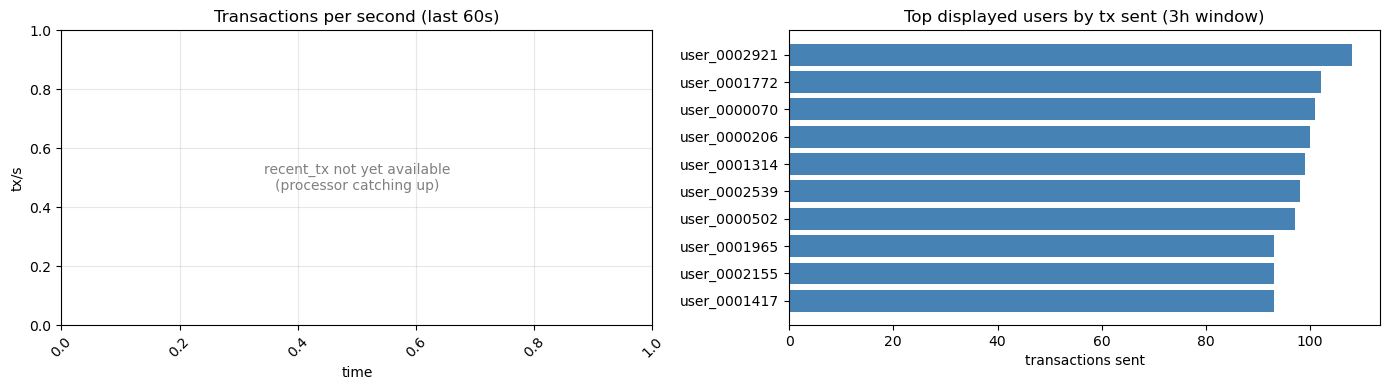


No anomalies among the displayed users.

(refresh 10/120  -  next update in 10s  -  interrupt the kernel to stop)
Dashboard stopped by user.


In [4]:
# --- Start the live auto-refreshing dashboard ------------------------------
# Interrupt the kernel (the square stop button) to stop the loop.
try:
    for i in range(ITERATIONS):
        render()
        print(f"\n(refresh {i + 1}/{ITERATIONS}  -  next update in "
              f"{REFRESH_SECONDS}s  -  interrupt the kernel to stop)")
        time.sleep(REFRESH_SECONDS)
    print("Reached the configured number of refreshes. Re-run this cell to continue.")
except KeyboardInterrupt:
    print("Dashboard stopped by user.")
